In [2]:
import pandas as pd
import numpy as np
import glob
import os
import re
from sklearn.model_selection import train_test_split

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
dataset_path = "../../../2026/**/*.csv"
all_files = glob.glob(dataset_path, recursive=True)
# Filter: exclude files dengan nama diawali "MASTER_DATA_EOI"
pattern = re.compile(r"^MASTER_DATA_EOI")

filtered_files = [
    file for file in all_files if not pattern.match(os.path.basename(file))
]

df_list = []
for file in filtered_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Gabungkan seluruh data
df_raw = pd.concat(df_list, ignore_index=True)

print(f"Total file ditemukan     : {len(all_files)}")
print(f"Total baris data awal    : {df_raw.shape[0]}")
df_raw.head()


Total file ditemukan     : 72
Total baris data awal    : 469225


,As At Month,Visa Type,Occupation,EOI Status,Points,Count EOIs,Nominated State,English Test Score
0,01/2026,190SAS Skilled Australian Sponsored,121321 Poultry Farmer,CLOSED,70,<20,ACT,0
1,01/2026,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,50,<20,ACT,0
2,01/2026,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,55,<20,ACT,0
3,01/2026,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,60,<20,ACT,0
4,01/2026,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,65,<20,ACT,0


In [4]:
df_raw["Count EOIs"] = df_raw["Count EOIs"].replace("<20", 10)


In [5]:
df_raw["Count EOIs"] = df_raw["Count EOIs"].astype(int)


In [6]:
feature_cols = [
    col for col in df_raw.columns if col not in ["As At Month", "EOI Status"]
]

# Temukan duplikat berdasarkan fitur saja
duplicates = df_raw[df_raw.duplicated(subset=feature_cols, keep=False)]
print(f"Jumlah baris duplikat: {len(duplicates)}")
duplicates.sort_values(feature_cols)


Jumlah baris duplikat: 426450


,As At Month,Visa Type,Occupation,EOI Status,Points,Count EOIs,Nominated State,English Test Score
89373,01/2026,190SAS Skilled Australian Sponsored,121212 Flower Grower,CLOSED,60,10,VIC,10
245172,02/2026,190SAS Skilled Australian Sponsored,121212 Flower Grower,CLOSED,60,10,VIC,10
403176,03/2026,190SAS Skilled Australian Sponsored,121212 Flower Grower,CLOSED,60,10,VIC,10
52407,01/2026,190SAS Skilled Australian Sponsored,121212 Flower Grower,CLOSED,65,10,NSW,10
207500,02/2026,190SAS Skilled Australian Sponsored,121212 Flower Grower,CLOSED,65,10,NSW,10
...,...,...,...,...,...,...,...,...
276136,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,LODGED,110,10,NSW,20
276142,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,CLOSED,110,10,NSW,20
434365,03/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,110,10,NSW,20
434366,03/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,LODGED,110,10,NSW,20


In [33]:
df_raw['Visa Type'].unique()

<StringArray>
['190SAS Skilled Australian Sponsored', '491SNR State or Territory Nominated - Regional']
Length: 2, dtype: str

In [199]:
key_cols = ["Occupation", "Visa Type", "Count EOIs", "Nominated State", "Points","English Test Score"]

# Kumpulkan keys per status
lodged_keys = set(
    df_raw[df_raw["EOI Status"] == "LODGED"][key_cols].apply(tuple, axis=1)
)
closed_keys = set(
    df_raw[df_raw["EOI Status"] == "CLOSED"][key_cols].apply(tuple, axis=1)
)
invited_keys = set(
    df_raw[df_raw["EOI Status"] == "INVITED"][key_cols].apply(tuple, axis=1)
)
hold_keys = set(
    df_raw[df_raw["EOI Status"] == "HOLD"][key_cols].apply(tuple, axis=1)
)
submitted_keys = set(
    df_raw[df_raw["EOI Status"] == "SUBMITTED"][key_cols].apply(tuple, axis=1)
)

lodged_or_invited_keys = lodged_keys | invited_keys  # gabungan

# SUBMITTED,INVITED,CLOSED dan HOLD YANG kombinasinya sudah ada di LODGED
mask_drop = (
    df_raw["EOI Status"].isin(["SUBMITTED", "INVITED","CLOSED","HOLD"])
) & df_raw[key_cols].apply(tuple, axis=1).isin(lodged_keys)


# Hapus CLOSED jika kombinasinya sudah ada di lodged
mask_closed = (
    df_raw["EOI Status"] == "CLOSED"
) & df_raw[key_cols].apply(tuple, axis=1).isin(lodged_keys)


# Gabungkan & drop 
mask_to_drop = mask_drop | mask_closed

df_clean = df_raw[~mask_to_drop].reset_index(drop=True)

print(f"Sebelum : {len(df_raw):,} baris")
print(f"Dihapus : {mask_to_drop.sum():,} baris")
print(f"Sesudah : {len(df_clean):,} baris")
print(f"\nDistribusi EOI Status setelah cleaning:")
print(df_clean["EOI Status"].value_counts())

Sebelum : 469,225 baris
Dihapus : 64,185 baris
Sesudah : 405,040 baris

Distribusi EOI Status setelah cleaning:
EOI Status
SUBMITTED    190577
CLOSED       163036
LODGED        38505
HOLD          11315
INVITED        1607
Name: count, dtype: int64


In [200]:
idx_to_drop = df_clean[df_clean["EOI Status"].isin(['INVITED','HOLD','SUBMITTED'])].index
df_clean = df_clean.drop(index=idx_to_drop).reset_index(drop=True)



In [201]:
df_clean["EOI Status"] = df_clean["EOI Status"].replace("CLOSED", "NOT LODGED")


In [202]:
mask_drop_visa = (
    df_clean["Visa Type"] == "491FSR Family Sponsored - Regional"
)

df_clean = df_clean[~mask_drop_visa].reset_index(drop=True)


In [203]:
#Anomaly Data (<65 points but in a lodged status)

df_hasil = df_clean[(df_clean["Points"] < 65) & (df_clean["EOI Status"] == "LODGED")]


In [204]:
#Drop datas that < 65 because it will automatically rejected when they want to lodge the visa

mask_drop_points= (df_clean["Points"]<65)

df_clean = df_clean[~mask_drop_points].reset_index(drop=True)


In [160]:
df_hasil['Points'].value_counts()

Points
60    358
55    143
Name: count, dtype: int64

In [68]:
df_clean[df_clean["EOI Status"] == "NOT LODGED"][key_cols].duplicated().sum()


np.int64(79335)

In [71]:
df_clean[df_clean["EOI Status"] == "LODGED"][key_cols].duplicated().sum()


np.int64(23192)

In [205]:
df_clean.describe()

,Points,Count EOIs,English Test Score
count,176874.000000,176874.000000,176874.000000
mean,81.181123,17.069106,10.836697
std,11.366931,34.132804,7.553621
min,65.000000,10.000000,0.000000
25%,70.000000,10.000000,10.000000
50%,80.000000,10.000000,10.000000
75%,90.000000,10.000000,20.000000
max,140.000000,1153.000000,20.000000


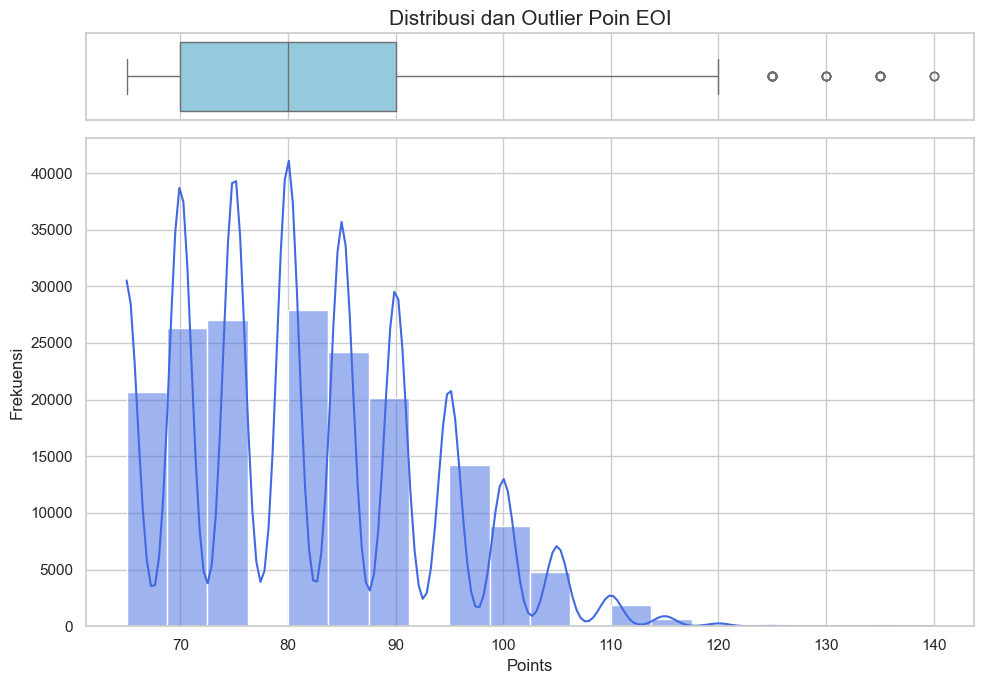

In [206]:


# Mengatur tema visual
sns.set_theme(style="whitegrid")

# Membuat figure dengan dua subplots (Boxplot di atas, Histogram di bawah)
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)}, figsize=(10, 7)
)

# 1. Menambahkan Boxplot (untuk melihat outlier dan median)
sns.boxplot(x=df_clean["Points"], ax=ax_box, color="skyblue")
ax_box.set(xlabel="")  # Menghilangkan label x pada boxplot agar rapi
ax_box.set_title("Distribusi dan Outlier Poin EOI", fontsize=15)

# 2. Menambahkan Histogram + KDE (Kurva Tren)
sns.histplot(df_clean["Points"], kde=True, ax=ax_hist, color="royalblue", bins=20)

# Menambahkan label
ax_hist.set_xlabel("Points", fontsize=12)
ax_hist.set_ylabel("Frekuensi", fontsize=12)

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()


In [226]:


# Membuat tabel silang antara Points dan EOI Status
summary_poin = pd.crosstab(df_clean["Points"], df_clean["EOI Status"])

# Tampilkan hasil
print(summary_poin)


EOI Status  LODGED  NOT LODGED
Points                        
65            3141       17550
70            4491       21861
75            4943       22091
80            5966       21957
85            5669       18530
90            5469       14696
95            3992       10233
100           2471        6346
105           1385        3414
110            477        2192


In [207]:
upper_limit = df_clean["Points"].quantile(0.99)
df_clean["Points"] = df_clean["Points"].clip(upper=upper_limit)


In [208]:
df_clean.describe()

,Points,Count EOIs,English Test Score
count,176874.000000,176874.000000,176874.000000
mean,81.149688,17.069106,10.836697
std,11.274504,34.132804,7.553621
min,65.000000,10.000000,0.000000
25%,70.000000,10.000000,10.000000
50%,80.000000,10.000000,10.000000
75%,90.000000,10.000000,20.000000
max,110.000000,1153.000000,20.000000


In [ ]:
# df_lodged = df_clean[df_clean["EOI Status"] != "NOT LODGED"]
# df_not_lodged = df_clean[df_clean["EOI Status"] == "NOT LODGED"]

# # 2. Hapus duplikat hanya di bagian NOT LODGED
# df_not_lodged_unique = df_not_lodged.drop_duplicates(subset=key_cols, keep='first')
# df_lodged_unique = df_lodged.drop_duplicates(subset=key_cols, keep="first")
# # 3. Gabungkan kembali
# df_clean = pd.concat([df_lodged_unique, df_not_lodged_unique], ignore_index=True)

In [209]:
from sklearn.preprocessing import LabelEncoder,StandardScaler


df_model = df_clean.copy()
le_occ = LabelEncoder()
Standardize = StandardScaler()
df_model = pd.get_dummies(df_model, columns=["Visa Type", "Nominated State"], dtype=int)
df_model["occupation_enc"] = le_occ.fit_transform(df_model["Occupation"])
df_model["Status_enc"]  = df_model['EOI Status'].map(
    {
        "NOT LODGED": 0,  
        "LODGED": 1
    }
)
drop_cols = ["Occupation", "As At Month", "EOI Status", "Status_enc"]
feature_cols = [c for c in df_model.columns if c not in drop_cols]


In [210]:
df_model['EOI Status'].value_counts()

EOI Status
NOT LODGED    138870
LODGED         38004
Name: count, dtype: int64

In [211]:
feature_cols


['Points',
 'Count EOIs',
 'English Test Score',
 'Visa Type_190SAS Skilled Australian Sponsored',
 'Visa Type_491SNR State or Territory Nominated - Regional',
 'Nominated State_ACT',
 'Nominated State_NSW',
 'Nominated State_NT',
 'Nominated State_QLD',
 'Nominated State_SA',
 'Nominated State_TAS',
 'Nominated State_VIC',
 'Nominated State_WA',
 'occupation_enc']

In [212]:
df_model[feature_cols].info()


<class 'pandas.DataFrame'>
RangeIndex: 176874 entries, 0 to 176873
Data columns (total 14 columns):
 #   Column                                                    Non-Null Count   Dtype
---  ------                                                    --------------   -----
 0   Points                                                    176874 non-null  int64
 1   Count EOIs                                                176874 non-null  int64
 2   English Test Score                                        176874 non-null  int64
 3   Visa Type_190SAS Skilled Australian Sponsored             176874 non-null  int64
 4   Visa Type_491SNR State or Territory Nominated - Regional  176874 non-null  int64
 5   Nominated State_ACT                                       176874 non-null  int64
 6   Nominated State_NSW                                       176874 non-null  int64
 7   Nominated State_NT                                        176874 non-null  int64
 8   Nominated State_QLD                

In [213]:
X = df_model[feature_cols]
y = df_model["Status_enc"]


In [214]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [215]:
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
)


In [216]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [217]:
# SMOTE hanya di training set
rus= SMOTE(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)
print(f"Train sebelum: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Train sesudah: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test (tidak diubah): {pd.Series(y_test).value_counts().to_dict()}")


Train sebelum: {0: 111086, 1: 30413}
Train sesudah: {0: 111086, 1: 111086}
Test (tidak diubah): {0: 27784, 1: 7591}


In [218]:
from xgboost import XGBClassifier

# Handle imbalance
scale_pos_weight = (y_train_bal == 1).sum() / (y_train_bal == 0).sum()

# Train model
model = XGBClassifier(
    n_estimators=1200,
    max_depth=11,
    learning_rate=0.07,
    subsample=1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
)


In [219]:
model.fit(X_train_bal, y_train_bal)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [220]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.93      0.93     27784
           1       0.75      0.77      0.76      7591

    accuracy                           0.90     35375
   macro avg       0.84      0.85      0.85     35375
weighted avg       0.90      0.90      0.90     35375



In [221]:
print("Points ada di feature_cols:", "Points" in feature_cols)
print(feature_cols)


Points ada di feature_cols: True
['Points', 'Count EOIs', 'English Test Score', 'Visa Type_190SAS Skilled Australian Sponsored', 'Visa Type_491SNR State or Territory Nominated - Regional', 'Nominated State_ACT', 'Nominated State_NSW', 'Nominated State_NT', 'Nominated State_QLD', 'Nominated State_SA', 'Nominated State_TAS', 'Nominated State_VIC', 'Nominated State_WA', 'occupation_enc']


In [222]:
from sklearn.metrics import f1_score

# Cek gap train vs test
train_f1 = f1_score(y_train, model.predict(X_train))
test_f1 = f1_score(y_test, model.predict(X_test))
print(f"Train F1 : {train_f1:.3f}")
print(f"Test  F1 : {test_f1:.3f}")
print(f"Gap      : {train_f1 - test_f1:.3f}")


Train F1 : 0.857
Test  F1 : 0.763
Gap      : 0.094


In [178]:
# Filter data hanya untuk label 1
label_1_data = X_train[y_train == 1]

# Cek variasi nilai (mean, std, min, max, dsb)
print(label_1_data[["Points"]].describe())


             Points
count  30411.000000
mean      83.335964
std       11.212451
min       65.000000
25%       75.000000
50%       85.000000
75%       90.000000
max      120.000000


In [179]:
# Filter data hanya untuk label 1
label_0_data = X_train[y_train == 0]

# Cek variasi nilai (mean, std, min, max, dsb)
print(label_0_data[["Points"]].describe())


              Points
count  111054.000000
mean       80.563375
std        11.317685
min        65.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       120.000000


In [ ]:
    
# Cek korelasi masing-masing ke Target (y_train)
corr_point = pd.Series(y_train).corr(X_train_bal["Points"])
print(f"Korelasi Points ke Target: {corr_point:.4f}")


Korelasi Points ke Target: 0.2886


In [180]:
# Tabel mapping lengkap
mapping = pd.DataFrame(
    {"occupation": le_occ.classes_, "encoded": range(len(le_occ.classes_))}
)

pd.set_option("display.max_rows", None)
print(mapping.to_string(index=False))
pd.reset_option("display.max_rows")


                                                  occupation  encoded
                                   121111 Aquaculture Farmer        0
                                        121212 Flower Grower        1
                                  121213 Fruit or Nut Grower        2
                     121214 Grain, Oilseed or Pasture Grower        3
                                         121215 Grape Grower        4
                                    121216 Mixed Crop Farmer        5
                                    121217 Sugar Cane Grower        6
                                     121221 Vegetable Grower        7
                                     121299 Crop Farmers nec        8
                                             121311 Apiarist        9
                                   121312 Beef Cattle Farmer       10
                                  121313 Dairy Cattle Farmer       11
                                        121316 Horse Breeder       12
                    

In [232]:
occ_dict = dict(zip(mapping["occupation"], mapping["encoded"]))

# ── Input ───────────────────────────────────────────────────
occupation_name = "233211 Civil Engineer"
English = 20
Points = 95
eoi_count = 100
state = "QLD"
visa_type = "190"  # "189", "190", atau "491"

# ── Mapping ─────────────────────────────────────────────────
STATE_COL_MAP = {
    "ACT": "State_ACT",
    "NSW": "State_NSW",
    "NT": "State_NT",
    "QLD": "State_QLD",
    "SA": "State_SA",
    "TAS": "State_TAS",
    "VIC": "State_VIC",
    "WA": "State_WA",
}

VISA_COL_MAP = {
    "189": "Visa Type_189SS Skilled Independent",  # ← sesuaikan nama kolom
    "190": "Visa Type_190SAS Skilled Australian Sponsored",
    "491": "Visa Type_491SNR State or Territory - Regional",
}

# ── Validasi input awal ──────────────────────────────────────
if state not in STATE_COL_MAP:
    raise ValueError(
        f"State '{state}' tidak valid! Pilih: {list(STATE_COL_MAP.keys())}"
    )

if visa_type not in VISA_COL_MAP:
    raise ValueError(
        f"Visa type '{visa_type}' tidak valid! Pilih: {list(VISA_COL_MAP.keys())}"
    )

# ── Encode occupation ────────────────────────────────────────
if occupation_name not in le_occ.classes_:
    raise ValueError(
        f"Occupation '{occupation_name}' tidak ditemukan di label encoder!"
    )

occ_enc = int(le_occ.transform([occupation_name])[0])

# ── Buat data dummy ──────────────────────────────────────────
data_dummy = pd.DataFrame(0, index=[0], columns=X_train.columns)
data_dummy["Count EOIs"] = eoi_count
data_dummy["occupation_enc"] = occ_enc
data_dummy['English Test Score'] = English
data_dummy["Points"] = Points
# Set State — FIX: sekarang pakai variabel state, bukan hardcode
state_col = STATE_COL_MAP[state]
if state_col in data_dummy.columns:
    data_dummy[state_col] = 1
else:
    print(f"⚠️  Kolom '{state_col}' tidak ada di training data!")

# Set Visa Type
visa_col = VISA_COL_MAP[visa_type]
if visa_col in data_dummy.columns:
    data_dummy[visa_col] = 1
else:
    print(f"⚠️  Kolom '{visa_col}' tidak ada di training data!")
    print(
        f"    Kolom visa yang tersedia: {[c for c in X_train.columns if 'Visa' in c]}"
    )

data_dummy = data_dummy.astype(float)

# ── Debug — cek kolom yang aktif ────────────────────────────
print("Kolom aktif (non-zero):")
print(data_dummy.loc[:, data_dummy.iloc[0] != 0].T.to_string())
print()

# ── Prediksi ─────────────────────────────────────────────────
prediksi_label = model.predict(data_dummy)[0]
prediksi_proba = model.predict_proba(data_dummy)[0]

status_map = {0: "NOT LODGED", 1: "LODGED"}
status = status_map.get(prediksi_label, str(prediksi_label))

# ── Output ───────────────────────────────────────────────────
print("=" * 55)
print("  HASIL PREDIKSI")
print("=" * 55)
print(f"  Occupation    : {occupation_name}")
print(f"  EOI Count     : {eoi_count}")
print(f"  State         : {state}")
print(f"  Visa Type     : {visa_type}")
print(f"  {'─' * 37}")
print(f"  Prediksi      : {status}")
print(f"  P(NOT LODGED) : {prediksi_proba[0] * 100:.2f}%")
print(f"  P(LODGED)     : {prediksi_proba[1] * 100:.2f}%")
print("=" * 55)


⚠️  Kolom 'State_QLD' tidak ada di training data!
Kolom aktif (non-zero):
                                                   0
Points                                          95.0
Count EOIs                                     100.0
English Test Score                              20.0
Visa Type_190SAS Skilled Australian Sponsored    1.0
occupation_enc                                 145.0

  HASIL PREDIKSI
  Occupation    : 233211 Civil Engineer
  EOI Count     : 100
  State         : QLD
  Visa Type     : 190
  ─────────────────────────────────────
  Prediksi      : NOT LODGED
  P(NOT LODGED) : 63.62%
  P(LODGED)     : 36.38%


In [145]:
df_model

,As At Month,Occupation,EOI Status,Points,Count EOIs,Visa Type_189PTS Points-Tested Stream,Visa Type_190SAS Skilled Australian Sponsored,Visa Type_491SNR State or Territory Nominated - Regional,Nominated State_ACT,Nominated State_NSW,Nominated State_NT,Nominated State_QLD,Nominated State_SA,Nominated State_TAS,Nominated State_VIC,Nominated State_WA,occupation_enc,Status_enc
0,03/2024,132311 Human Resource Manager,NOT LODGED,65,10,0,1,0,1,0,0,0,0,0,0,0,22,0
1,03/2024,135199 ICT Managers nec,NOT LODGED,55,10,0,1,0,1,0,0,0,0,0,0,0,44,0
2,03/2024,212413 Print Journalist,NOT LODGED,65,10,0,1,0,1,0,0,0,0,0,0,0,79,0
3,03/2024,212413 Print Journalist,NOT LODGED,80,10,0,1,0,1,0,0,0,0,0,0,0,79,0
4,03/2024,212415 Technical Writer,NOT LODGED,75,10,0,1,0,1,0,0,0,0,0,0,0,80,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558187,02/2026,639211 Retail Buyer,NOT LODGED,70,10,0,0,1,0,0,0,0,0,0,0,1,475,0
558188,02/2026,639211 Retail Buyer,NOT LODGED,75,10,0,0,1,0,0,0,0,0,0,0,1,475,0
558189,02/2026,639211 Retail Buyer,NOT LODGED,80,10,0,0,1,0,0,0,0,0,0,0,1,475,0
558190,02/2026,639211 Retail Buyer,NOT LODGED,85,10,0,0,1,0,0,0,0,0,0,0,1,475,0


In [146]:
# Konfirmasi dengan correlation
print(df_model[["Count EOIs", "Status_enc"]].corr())

# Atau point-biserial correlation
from scipy.stats import pointbiserialr

corr, pval = pointbiserialr(df_model["Status_enc"], df_model["Count EOIs"])
print(f"Correlation : {corr:.4f}")
print(f"P-value     : {pval:.4e}")


            Count EOIs  Status_enc
Count EOIs    1.000000   -0.133772
Status_enc   -0.133772    1.000000
Correlation : -0.1338
P-value     : 0.0000e+00


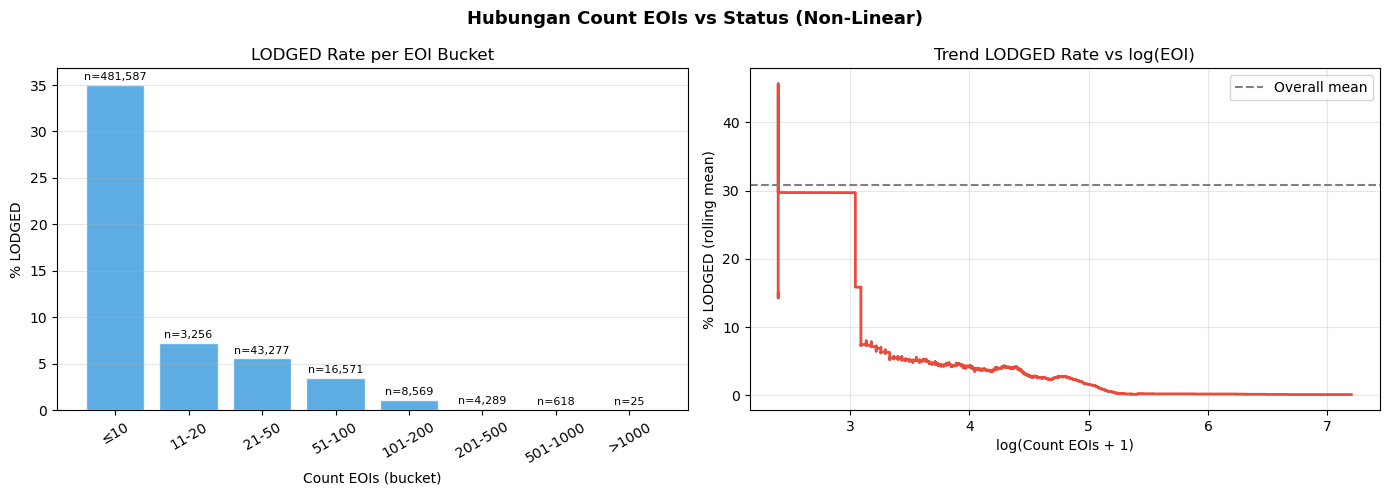


LODGED rate per EOI bucket:
 EOI_bin  lodged_rate  count
     ≤10     0.350481 481587
   11-20     0.072174   3256
   21-50     0.055896  43277
  51-100     0.035061  16571
 101-200     0.011203   8569
 201-500     0.001399   4289
501-1000     0.000000    618
   >1000     0.000000     25


In [147]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Hubungan Count EOIs vs Status (Non-Linear)", fontsize=13, fontweight="bold"
)

# ── Plot 1: Binned Mean — pecah EOI ke bucket ────────────────
bins = [0, 10, 20, 50, 100, 200, 500, 1000, 99999]
labels = ["≤10", "11-20", "21-50", "51-100", "101-200", "201-500", "501-1000", ">1000"]

df_model["EOI_bin"] = pd.cut(df_model["Count EOIs"], bins=bins, labels=labels)

bin_stats = (
    df_model.groupby("EOI_bin", observed=True)["Status_enc"]
    .agg(lodged_rate="mean", count="count")
    .reset_index()
)

axes[0].bar(
    bin_stats["EOI_bin"],
    bin_stats["lodged_rate"] * 100,
    color="#3498db",
    alpha=0.8,
    edgecolor="white",
)
axes[0].set_xlabel("Count EOIs (bucket)")
axes[0].set_ylabel("% LODGED")
axes[0].set_title("LODGED Rate per EOI Bucket")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

# Tambah label count
for i, row in bin_stats.iterrows():
    axes[0].text(
        i,
        row["lodged_rate"] * 100 + 0.5,
        f"n={row['count']:,}",
        ha="center",
        fontsize=8,
    )

# ── Plot 2: Log EOI vs LODGED rate (rolling) ─────────────────
df_temp = df_model[["Count EOIs", "Status_enc"]].copy()
df_temp["log_eoi"] = np.log1p(df_temp["Count EOIs"])
df_temp = df_temp.sort_values("log_eoi")
df_temp["rolling_lodged"] = (
    df_temp["Status_enc"].rolling(window=5000, min_periods=100).mean()
)

axes[1].plot(
    df_temp["log_eoi"], df_temp["rolling_lodged"] * 100, color="#e74c3c", linewidth=2
)
axes[1].set_xlabel("log(Count EOIs + 1)")
axes[1].set_ylabel("% LODGED (rolling mean)")
axes[1].set_title("Trend LODGED Rate vs log(EOI)")
axes[1].grid(alpha=0.3)
axes[1].axhline(
    df_model["Status_enc"].mean() * 100,
    color="gray",
    linestyle="--",
    label="Overall mean",
)
axes[1].legend()

plt.tight_layout()
plt.savefig("eoi_nonlinear.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLODGED rate per EOI bucket:")
print(bin_stats.to_string(index=False))


In [149]:
# ── Cek outlier ──────────────────────────────────────────────
import numpy as np

print("=" * 50)
print("  CEK OUTLIER Count EOIs")
print("=" * 50)

# 1. Persentase outlier di berbagai threshold
thresholds = [500, 1000, 1339, 2000, 5000]
for t in thresholds:
    n = (df_model["Count EOIs"] > t).sum()
    pct = n / len(df_model) * 100
    lodged = df_model[df_model["Count EOIs"] > t]["Status_enc"].mean() * 100
    print(f"  EOI > {t:>5} : {n:>6,} baris ({pct:.2f}%) | LODGED rate: {lodged:.1f}%")

# 2. IQR method
Q1 = df_model["Count EOIs"].quantile(0.25)
Q3 = df_model["Count EOIs"].quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR
n_iqr = (df_model["Count EOIs"] > upper_iqr).sum()
print(f"\n  IQR upper bound : {upper_iqr:.1f}")
print(f"  Outlier (IQR)   : {n_iqr:,} baris ({n_iqr / len(df_model) * 100:.2f}%)")

# 3. LODGED rate dengan vs tanpa outlier
no_outlier = df_model[df_model["Count EOIs"] <= upper_iqr]
with_outlier = df_model

print(
    f"\n  LODGED rate WITH outlier    : {with_outlier['Status_enc'].mean() * 100:.2f}%"
)
print(f"  LODGED rate WITHOUT outlier : {no_outlier['Status_enc'].mean() * 100:.2f}%")


  CEK OUTLIER Count EOIs
  EOI >   500 :    643 baris (0.12%) | LODGED rate: 0.0%
  EOI >  1000 :     25 baris (0.00%) | LODGED rate: 0.0%
  EOI >  1339 :      0 baris (0.00%) | LODGED rate: nan%
  EOI >  2000 :      0 baris (0.00%) | LODGED rate: nan%
  EOI >  5000 :      0 baris (0.00%) | LODGED rate: nan%

  IQR upper bound : 10.0
  Outlier (IQR)   : 76,605 baris (13.72%)

  LODGED rate WITH outlier    : 30.84%
  LODGED rate WITHOUT outlier : 35.05%


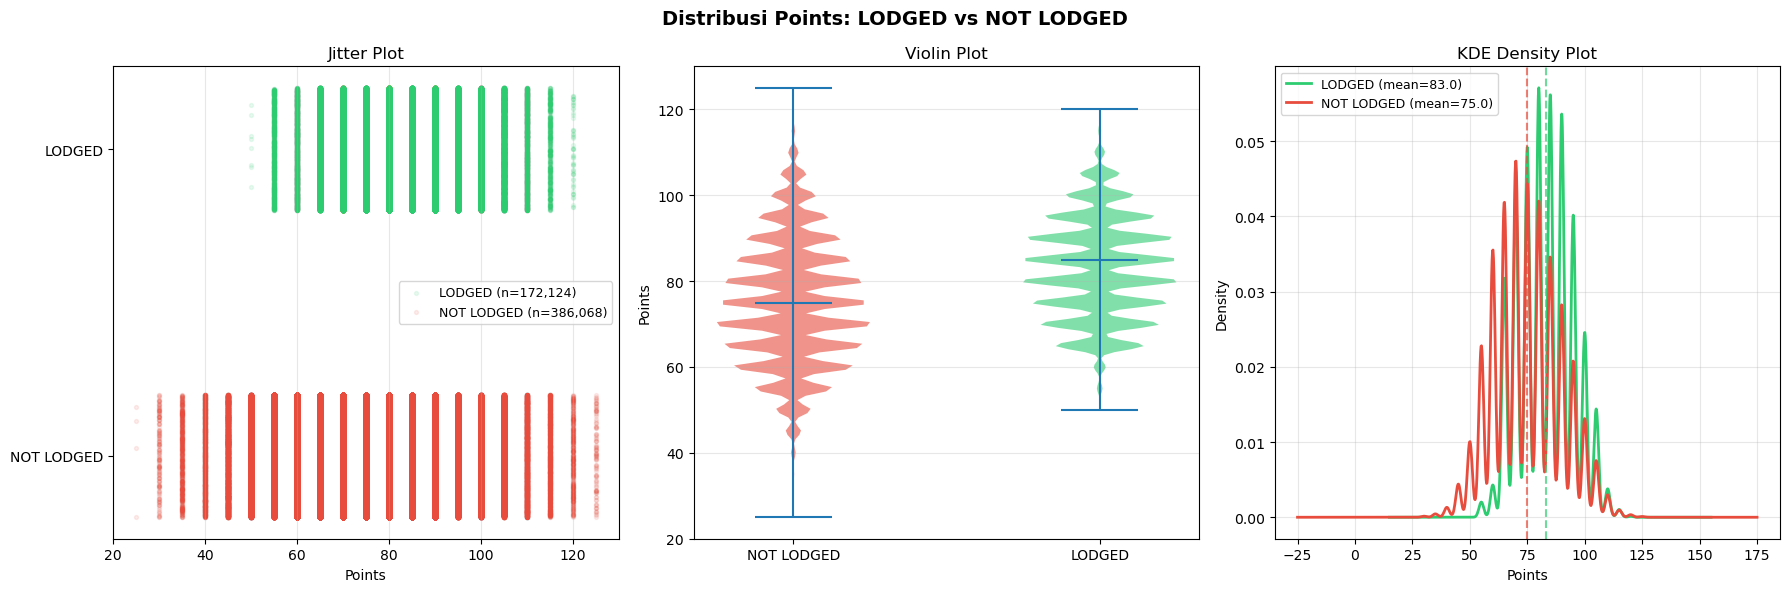

✅ Plot tersimpan: distribusi_points_status.png


In [139]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribusi Points: LODGED vs NOT LODGED", fontsize=14, fontweight="bold")

lodged = df_clean[df_clean["EOI Status"] == "LODGED"]
not_lodged = df_clean[df_clean["EOI Status"] == "NOT LODGED"]

# ── Plot 1: Jitter Plot ──────────────────────────────────────
ax = axes[0]
np.random.seed(42)

jitter_lodged = np.random.uniform(0.8, 1.2, len(lodged))
jitter_not_lodged = np.random.uniform(-0.2, 0.2, len(not_lodged))

ax.scatter(
    lodged["Points"],
    jitter_lodged,
    color="#2ecc71",
    alpha=0.1,
    s=8,
    label=f"LODGED (n={len(lodged):,})",
)
ax.scatter(
    not_lodged["Points"],
    jitter_not_lodged,
    color="#e74c3c",
    alpha=0.1,
    s=8,
    label=f"NOT LODGED (n={len(not_lodged):,})",
)

ax.set_yticks([0, 1])
ax.set_yticklabels(["NOT LODGED", "LODGED"])
ax.set_xlabel("Points")
ax.set_title("Jitter Plot")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# ── Plot 2: Violin Plot ──────────────────────────────────────
ax = axes[1]
parts = ax.violinplot(
    [not_lodged["Points"], lodged["Points"]],
    positions=[0, 1],
    showmedians=True,
    showextrema=True,
)

# Warna violin
parts["bodies"][0].set_facecolor("#e74c3c")
parts["bodies"][1].set_facecolor("#2ecc71")
for body in parts["bodies"]:
    body.set_alpha(0.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(["NOT LODGED", "LODGED"])
ax.set_ylabel("Points")
ax.set_title("Violin Plot")
ax.grid(axis="y", alpha=0.3)

# ── Plot 3: KDE / Density Overlap ───────────────────────────
ax = axes[2]
lodged["Points"].plot.kde(
    ax=ax,
    color="#2ecc71",
    linewidth=2,
    label=f"LODGED (mean={lodged['Points'].mean():.1f})",
)
not_lodged["Points"].plot.kde(
    ax=ax,
    color="#e74c3c",
    linewidth=2,
    label=f"NOT LODGED (mean={not_lodged['Points'].mean():.1f})",
)

ax.axvline(lodged["Points"].mean(), color="#2ecc71", linestyle="--", alpha=0.7)
ax.axvline(not_lodged["Points"].mean(), color="#e74c3c", linestyle="--", alpha=0.7)
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("KDE Density Plot")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [100]:
# ── DEEP DIAGNOSTIC ─────────────────────────────────────────

# 1. Ambil baris dari X_train yang mirip dengan input kamu
similar = X_train[
    (X_train["Points"].between(55, 65))
    & (X_train["Count EOIs"].between(10, 50))
    & (X_train["occupation_enc"] == occ_enc)
]
print(f"[1] Baris mirip di training: {len(similar)}")
if len(similar) > 0:
    print(similar.head())
    # Cek label-nya
    print("\nLabel distribusi baris mirip:")
    print(y_train.loc[similar.index].value_counts())

# 2. Coba predict langsung pakai baris dari training
print("\n[2] Predict dari baris training yang mirip:")
if len(similar) > 0:
    sample = similar.head(3)
    print(model.predict_proba(sample))
    print("Labels:", y_train.loc[sample.index].values)

# 3. Cek apakah occupation_enc 290 ada di training
occ_in_train = X_train[X_train["occupation_enc"] == occ_enc]
print(f"\n[3] Baris dengan occupation_enc=290 di training: {len(occ_in_train)}")
print("Label distribusi:")
print(y_train.loc[occ_in_train.index].value_counts())

# 4. Cek class distribution keseluruhan
print(f"\n[4] Class distribution y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))


[1] Baris mirip di training: 0

[2] Predict dari baris training yang mirip:

[3] Baris dengan occupation_enc=290 di training: 134
Label distribusi:
Status_enc
0    126
1      8
Name: count, dtype: int64

[4] Class distribution y_train:
Status_enc
0    308587
1    137966
Name: count, dtype: int64
Status_enc
0    0.691
1    0.309
Name: proportion, dtype: float64


In [95]:
# ── DIAGNOSTIC LANJUTAN ──────────────────────────────────────

# 1. Cek statistik fitur numerik di training data
print("[1] Statistik X_train (fitur utama):")
print(X_train[["Points", "Count EOIs", "occupation_enc"]].describe())

# 2. Cek berapa % data training yang Points = 60 & EOI = 2000
print("\n[2] Distribusi Points di training:")
print(X_train["Points"].value_counts().sort_index())

print("\n[3] Distribusi Count EOIs di training:")
print(X_train["Count EOIs"].describe())

# 3. Cek apakah kombinasi Points=60 & EOI=2000 ada di training
match = X_train[(X_train["Points"] == 60) & (X_train["Count EOIs"] == 2000)]
print(f"\n[4] Baris di training dengan Points=60 & EOI=2000: {len(match)}")

# 4. Cek feature importance
if hasattr(model, "feature_importances_"):
    fi = pd.Series(model.feature_importances_, index=X_train.columns)
    print("\n[5] Top 10 Feature Importance:")
    print(fi.sort_values(ascending=False).head(10))


[1] Statistik X_train (fitur utama):
              Points     Count EOIs  occupation_enc
count  446553.000000  446553.000000   446553.000000
mean       77.501114      18.425562      219.465981
std        14.170488      39.198162      124.498479
min        25.000000      10.000000        0.000000
25%        65.000000      10.000000      120.000000
50%        75.000000      10.000000      196.000000
75%        90.000000      10.000000      317.000000
max       125.000000    1339.000000      475.000000

[2] Distribusi Points di training:
Points
25         4
30       118
35       381
40      1149
45      3807
50      8625
55     20272
60     31772
65     47571
70     56470
75     56007
80     56806
85     50083
90     43642
95     32389
100    20278
105    11651
110     3910
115     1207
120      334
125       77
Name: count, dtype: int64

[3] Distribusi Count EOIs di training:
count    446553.000000
mean         18.425562
std          39.198162
min          10.000000
25%          10.00000

In [102]:
# 3. Cek apakah occupation_enc 290 ada di training
occ_in_train = X_train[X_train["occupation_enc"] == occ_enc]
print(f"\n[3] Baris dengan occupation_enc=290 di training: {len(occ_in_train)}")
print("Label distribusi:")
print(y_train.loc[occ_in_train.index].value_counts())

# 4. Cek class distribution keseluruhan
print(f"\n[4] Class distribution y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))



[3] Baris dengan occupation_enc=290 di training: 134
Label distribusi:
Status_enc
0    126
1      8
Name: count, dtype: int64

[4] Class distribution y_train:
Status_enc
0    308587
1    137966
Name: count, dtype: int64
Status_enc
0    0.691
1    0.309
Name: proportion, dtype: float64


In [77]:
data_dummy

,Points,Count EOIs,Visa Type_189PTS Points-Tested Stream,Visa Type_190SAS Skilled Australian Sponsored,Visa Type_491SNR State or Territory Nominated - Regional,Nominated State_ACT,Nominated State_NSW,Nominated State_NT,Nominated State_QLD,Nominated State_SA,Nominated State_TAS,Nominated State_VIC,Nominated State_WA,occupation_enc
0,100.0,2000.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,290.0


In [57]:
prediksi_proba

array([1.0000000e+00, 1.2014764e-09], dtype=float32)

In [426]:
data_dummy

,Points,Count EOIs,Visa Type_190SAS Skilled Australian Sponsored,Visa Type_491SNR State or Territory Nominated - Regional,Nominated State_ACT,Nominated State_NSW,Nominated State_NT,Nominated State_QLD,Nominated State_SA,Nominated State_TAS,Nominated State_VIC,Nominated State_WA,occupation_enc
0,90.0,20.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,387.0
